# Agentic RAG with Self-Correction


# Problem Statement / Use Case Overview

A standard RAG pipeline follows one fixed path: retrieve some chunks, hand them to the LLM, get an answer back. It never stops to check whether the chunks it found are actually any good. If the retrieval step pulls back weak or unrelated text, the LLM still has to answer with whatever it was given, and the final answer suffers as a result.


### How This Lab Solves It

This lab builds a version that adds a checkpoint in the middle of that path. Before answering, the pipeline stops and asks the LLM a second question: "Do these retrieved chunks actually help answer this?" If the answer is no, the original question is rewritten into a clearer, easier-to-search version, and retrieval is tried again — up to a set number of times — before the pipeline finally answers using whatever it has. This back-and-forth is called **self-correction**, and it's what turns a simple RAG pipeline into an **agent**: something that can evaluate its own progress and decide what to do next, rather than always moving forward in a straight line.

To make that kind of decision-making possible, this pipeline is built with **LangGraph**, a library for wiring individual steps together into a graph, where the path taken can branch and loop depending on what happens at each step — instead of every step just running once, in order, like a plain script.

**This pipeline has four connected parts, wired together as a loop:**

1. **Retrieve** — find the chunks of text closest in meaning to the current question.
2. **Grade** — ask the LLM whether those chunks are actually useful.
3. **Rewrite** — if they're not useful, and retries remain, ask the LLM to rephrase the question and try retrieval again.
4. **Generate** — once the chunks are judged useful (or retries run out), answer the question using only those chunks.

This is useful for:
- **Vague or awkwardly phrased questions** — the rewrite step gives the pipeline a second (or third) chance to phrase the question in a way retrieval can actually work with.
- **Avoiding answers built on weak context** — the grading step acts as a quality gate before the LLM is ever asked to answer.
- **Any workflow where a fixed number of steps isn't enough** — LangGraph makes it possible to loop back and retry, something a simple top-to-bottom script can't do on its own.


# Input Data

| Item | Detail |
|------|--------|
| **The PDF** | A document downloaded automatically from a link |
| **Your question** | A natural-language question about the document |
| **LLM API Key** | Used to grade retrieved chunks, rewrite questions, and generate the final answer |
| **Embedding model** | Runs locally — no API key needed, downloaded automatically the first time it's used |


# Processing


### Part A — Ingestion

Before any question can be answered, the PDF has to be turned into a searchable knowledge base:

```mermaid
flowchart LR
    PDF["PDF link"] --> DL["Download PDF"]
    DL --> EX["Extract text"]
    EX --> CH["Split into overlapping chunks"]
    CH --> EMB["Embed chunks locally"]
    EMB --> KB[("Knowledge base of vectors")]

    classDef ingestStyle fill:#eef7ee,stroke:#3a7d3a,stroke-width:1px,color:#111111
    class PDF,DL,EX,CH,EMB,KB ingestStyle
```

The PDF is downloaded, its text is extracted and split into overlapping chunks, and every chunk is embedded into a vector once, up front. This knowledge base of vectors is what the retrieve step searches against on every attempt, including any rewritten questions later in the loop.


### Part B — The Self-Correction Loop

```mermaid
flowchart LR
    Q["Question"] --> R["Retrieve closest chunks"]
    R --> G{"Grade: are these chunks useful?"}
    G -->|"YES"| Gen["Generate final answer"]
    G -->|"NO - retries left"| RW["Rewrite the question"]
    RW --> R
    G -->|"NO - out of retries"| Gen

    classDef defaultStyle fill:#ffffff,stroke:#333333,stroke-width:1px,color:#111111
    classDef decisionStyle fill:#fff3cd,stroke:#d68f00,stroke-width:1px,color:#1a1a1a
    class Q,R,RW,Gen defaultStyle
    class G decisionStyle
```

This is the shape of the whole pipeline: retrieval feeds into a grading check, and that check decides what happens next. A good grade sends the flow straight to the final answer. A bad grade sends it back through a rewrite step and another round of retrieval — but only if retries are still available. Once the retry limit is reached, the pipeline stops looping and answers with whatever it has, rather than getting stuck trying forever.


### Part C — How the Pipeline Is Wired

LangGraph turns each of the four steps above into a **node**, and the arrows between them into **edges**. Most edges are fixed — retrieval always leads to grading — but the edge coming out of the grading step is a **conditional edge**: it looks at the grade and chooses which node to go to next, rather than always going to the same one.

```mermaid
flowchart LR
    StartNode(["START"]) --> retrieve["retrieve"]
    retrieve --> grade["grade"]
    grade -->|"generate"| generate["generate"]
    grade -->|"rewrite"| rewrite["rewrite"]
    rewrite --> retrieve
    generate --> EndNode(["END"])

    classDef defaultStyle fill:#ffffff,stroke:#333333,stroke-width:1px,color:#111111
    classDef terminalStyle fill:#e7f1ff,stroke:#1d6fa5,stroke-width:1px,color:#0b1f33
    class retrieve,grade,rewrite,generate defaultStyle
    class StartNode,EndNode terminalStyle
```

This is the actual structure the notebook builds — the same diagram it produces when the graph is rendered. `retrieve` and `grade` always run in that order. From `grade`, the routing function decides whether to continue on to `generate` or to loop back through `rewrite`. `rewrite` always leads back to `retrieve`, closing the loop, while `generate` is the only node that leads to `END`.


### Walking Through a Retry, Step by Step

The example run in this lab happens to get a good grade on the very first try, so the loop only runs once. To show what the retry path actually looks like, here's how the state would move through two attempts if the first one came back with a **NO**:

```mermaid
flowchart TB
    subgraph A1["Attempt 1"]
        Q1["question: original wording"] --> R1["retrieve top chunks"] --> G1["grade: NO"]
    end

    G1 -->|"retry_count 0 to 1"| RW1["rewrite the question"]

    subgraph A2["Attempt 2"]
        Q2["question: rewritten wording"] --> R2["retrieve top chunks"] --> G2["grade: YES"]
    end

    RW1 --> Q2
    G2 --> Gen["generate final answer"]

    classDef defaultStyle fill:#ffffff,stroke:#333333,stroke-width:1px,color:#111111
    class Q1,R1,G1,RW1,Q2,R2,G2,Gen defaultStyle

    style A1 fill:#eef3fb,stroke:#5b7fa6,stroke-width:1px,color:#1a1a1a
    style A2 fill:#eef3fb,stroke:#5b7fa6,stroke-width:1px,color:#1a1a1a
```

Two things change between attempts: the question itself gets replaced with a rewritten version, and `retry_count` goes up by one. That counter is what stops the loop from running forever — once it reaches the limit set in the routing function, the pipeline moves on to `generate` regardless of the grade, using the best chunks it managed to find.


# Output

**Configuring the LLM** confirms the connection:

```
LLM configured successfully!
```

**Downloading and extracting the PDF** prints the character count pulled from it:

```
Downloading PDF from link: https://arxiv.org/pdf/1706.03762.pdf...
PDF downloaded successfully to data/downloaded_paper.pdf!
Extracted 1500 characters of text.
```

**Splitting the text into chunks** prints how many pieces it was broken into:

```
Knowledge base ready with 6 intelligent chunks.
```

**Embedding the chunks** confirms once every chunk has a vector:

```
Chunks embedded successfully!
```


**Building the agent graph** confirms the nodes and edges compiled correctly:

```
Agent graph compiled successfully!
```

**Running the agent** on the question *"How does the Transformer work?"* prints the retrieval step, the grade, and finally the two-part answer:

```
Retrieving for: 'How does the Transformer work?'
Grade: YES

--- FINAL ANSWER ---
The Transformer is a sequence-to-sequence model that uses only attention
mechanisms to link its encoder and decoder, eliminating recurrence and
convolutions.

--- EXPLAINABILITY ---
We used the fact that performing models connect the encoder and decoder
through an attention mechanism, that the Transformer is a new simple
architecture based solely on attention mechanisms, and that it dispenses
with recurrence and convolutions, contrasting with dominant sequence
transduction models that rely on complex recurrent or convolutional
neural networks.
```

The grade came back `YES` on the first attempt here, so the loop never had to rewrite the question — the retrieved chunks were good enough on the very first pass.


# Tech Stack

| Component | Tool |
|---|---|
| **PDF Text Extraction** | `pypdf` — pulls raw text out of the PDF |
| **File Downloading** | `requests` — grabs the PDF from a link |
| **Text Chunking** | `langchain-text-splitters` (`RecursiveCharacterTextSplitter`) — breaks the document into overlapping chunks |
| **Embedding Model** | `sentence-transformers` / `all-MiniLM-L6-v2`, via `langchain-huggingface` — runs locally, produces 384-dimension vectors |
| **Similarity Search** | `scikit-learn` (`cosine_similarity`) — compares the question's vector against every chunk's vector |
| **LLM (Grading, Rewriting, Answering)** | `openai/gpt-oss-20b:free`, accessed through `langchain-openai`'s `ChatOpenAI` wrapper |
| **Agent Orchestration** | `langgraph` — wires the retrieve, grade, rewrite, and generate steps into a loopable graph |


# Underlying Concepts (Summarized)

**Agent** here means a pipeline that doesn't just run its steps once from top to bottom — it checks its own progress partway through and decides what to do next, based on that check. The decision to loop back and try again, rather than move forward blindly, is what separates an agent from a plain script.

**State** is the information the agent carries with it as it moves between steps — the current question, the chunks retrieved so far, the latest grade, how many retries have happened, and the final answer once it's ready. Every node reads from this state and updates it before passing it along.

**LangGraph** is the library used to build the agent as a graph of **nodes** (the individual steps) connected by **edges** (the paths between them). A **conditional edge** is an edge that picks its destination at run time, based on the state — that's what lets the grading step send the flow to either `generate` or `rewrite`.

**Self-Correction** is the pattern of checking a result, and going back to improve it if the check fails, instead of accepting the first attempt no matter what. Here, that means grading the retrieved chunks and rewriting the question if they fall short.

**Cosine Similarity** is a way of measuring how close two vectors are in meaning, regardless of their length. The retrieval step uses it to rank every chunk against the current question and pick the closest matches.

**Chunking with Overlap** means splitting a long document into smaller pieces, with a small amount of shared text between neighboring pieces, so that a sentence sitting right at a chunk boundary doesn't get cut in half and lose its meaning.

**Retry Limit** is a safeguard that caps how many times the loop is allowed to repeat. Without it, a question that never gets a good grade could send the agent back through rewrite and retrieval indefinitely.

> **Why this matters:** A plain RAG pipeline has no way to notice when its own retrieval step has failed — it just answers anyway. Here, the grading step catches that failure before it reaches the final answer, and the rewrite step gives the question another chance to succeed, all without any manual intervention.


# Pre-requisites

- **Basic familiarity** with Python (functions, loops, `import` statements, dictionaries).
- **An LLM API Key** — used for grading, rewriting, and generating answers.
- **A general sense of what RAG and embeddings are** — retrieving relevant text using vector similarity before asking an LLM to answer.


## Getting an OpenRouter API Key

The LLM used here is accessed through OpenRouter, which provides a single API key that works across many different models, including free ones.

1. Go to [openrouter.ai](https://openrouter.ai) and sign up, or log in if an account already exists.
2. From the dashboard, open the **Keys** section.
3. Click **Create Key**, give it a name, and confirm.
4. **Copy the key immediately** — it's shown in full only once. If it's missed, a new key has to be created.
5. Store the key as an environment variable (`OPENROUTER_API_KEY`) rather than pasting it directly into the notebook, so it isn't exposed if the file is shared.

Once the key is set, the LLM configuration in the next section will pick it up automatically.


# Environment / Dependencies Setup

The cell below installs all required Python packages:

| Package | Purpose |
|---------|---------|
| `langgraph` | **Agent orchestration** — builds the graph of nodes and edges |
| `langchain-openai` | Wraps the LLM in LangChain's `ChatOpenAI` interface |
| `langchain-huggingface` | Wraps the local embedding model |
| `pypdf` | **PDF text extraction** |
| `requests` | Downloads the PDF from a link |
| `scikit-learn` | Provides `cosine_similarity` for comparing vectors |

> **Note:** Run this cell first — it only needs to be run once per session.


In [1]:
!pip install -qU langgraph langchain-openai langchain-huggingface pypdf requests scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step-wise Instructions — Development


### Step 1 — Imports


In [6]:
import os
import requests
from pypdf import PdfReader
from typing import TypedDict, List
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from sklearn.metrics.pairwise import cosine_similarity
from langgraph.graph import StateGraph, START, END

| Import | Purpose |
|---|---|
| `os` | File paths and folders |
| `requests` | Downloads the PDF |
| `PdfReader` | Extracts raw text from the PDF |
| `TypedDict`, `List` | Define the exact shape of the agent's state |
| `RecursiveCharacterTextSplitter` | Splits the document into overlapping chunks |
| `ChatOpenAI` | LangChain's wrapper for calling the LLM |
| `HuggingFaceEmbeddings` | Loads the local embedding model |
| `cosine_similarity` | Compares the question's vector against every chunk's vector |
| `StateGraph`, `START`, `END` | Build and cap the agent's graph |


### Step 2 — Configure the LLM


In [ ]:
llm = ChatOpenAI(
    openai_api_key="your-api-key",
    openai_api_base="https://openrouter.ai/api/v1",
    model_name="openai/gpt-oss-20b:free",
    temperature=0.0
)
print("LLM configured successfully!")

LLM configured successfully!


> **Note:** Replace `"your-api-key"` with the actual key from OpenRouter. To avoid pasting it directly into the notebook, it can instead be loaded with `os.getenv("OPENROUTER_API_KEY")` after setting it as an environment variable — for example, `openai_api_key=os.getenv("OPENROUTER_API_KEY")` — which keeps the actual key out of the file itself. `temperature=0.0` keeps grading, rewriting, and answering consistent, which matters since the grading step needs a reliable YES or NO.

This one LLM connection is reused for all three of the agent's thinking steps — grading, rewriting, and generating — so it only needs to be set up once.


### Step 3 — Download PDF and Extract Text


In [8]:
os.makedirs("data", exist_ok=True)

PDF_URL = "https://arxiv.org/pdf/1706.03762.pdf"
PDF_FILENAME = "data/downloaded_paper.pdf"

print(f"Downloading PDF from link: {PDF_URL}...")
response = requests.get(PDF_URL)
response.raise_for_status()

with open(PDF_FILENAME, "wb") as f:
    f.write(response.content)
print(f"PDF downloaded successfully to {PDF_FILENAME}!")

reader = PdfReader(PDF_FILENAME)
document_text = ""
for page in reader.pages:
    document_text += page.extract_text() + "\n"
    if len(document_text) >= 1500:
        document_text = document_text[:1500]
        break

print(f"Extracted {len(document_text)} characters of text.")

PDF downloaded successfully to data/downloaded_paper.pdf!
Extracted 1500 characters of text.


By the end of this step, `document_text` holds a short block of plain text pulled from the PDF, ready to be split into chunks.


### Step 4 — Split the Text into Chunks


In [9]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ".", " ", ""]
)

knowledge_base = text_splitter.split_text(document_text)

print(f"Knowledge base ready with {len(knowledge_base)} intelligent chunks.")

Knowledge base ready with 6 intelligent chunks.


The `separators` list tells the splitter what to break on first — it tries paragraph breaks, then line breaks, then sentence endings, and only falls back to breaking mid-sentence if nothing else fits within `chunk_size`. The `chunk_overlap` of 50 characters means neighboring chunks share a small amount of text, so context near a chunk boundary isn't lost entirely. By the end of this step, `knowledge_base` holds a list of short text chunks, ready to be turned into vectors.


### Step 5 — Load the Embedding Model and Embed the Chunks


In [10]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
knowledge_vectors = embeddings.embed_documents(knowledge_base)
print("Chunks embedded successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Chunks embedded successfully!


`all-MiniLM-L6-v2` is a small, fast embedding model that runs locally rather than through an API call. By the end of this step, `knowledge_vectors` holds one vector per chunk, in the same order as `knowledge_base`, ready to be compared against future questions.


### Step 6 — Define the Agent's State


In [11]:
class AgentState(TypedDict):
    question: str               # the current question (may get rewritten)
    retrieved_facts: List[str]  # facts found so far
    grade: str                   # YES or NO from the grading step
    retry_count: int            # how many times we've tried again
    final_answer: str           # filled in only at the end

This defines the exact shape of the information that gets passed between nodes. Every node in the graph receives the current state, changes part of it, and passes the whole thing along to the next node — so this class is effectively the shared notebook the whole agent writes into as it works.


### Step 7 — Retrieve Node


In [12]:
def retrieve_node(state: AgentState) -> AgentState:
    print(f"Retrieving for: '{state['question']}'")

    question_vector = embeddings.embed_query(state["question"])

    scores = cosine_similarity([question_vector], knowledge_vectors)[0]
    # Sort scores from lowest to highest, take the last 2 (highest), then reverse so the best match comes first
    top_indices = scores.argsort()[-2:][::-1]

    state["retrieved_facts"] = [knowledge_base[i] for i in top_indices]
    return state

The current question is embedded the same way the chunks were, so both sides can be compared fairly. `cosine_similarity` scores every chunk against that question vector, and the two highest-scoring chunks are pulled out and saved into `state["retrieved_facts"]`. Because this node reads `state["question"]` rather than a fixed value, it automatically picks up a rewritten question if the loop comes back around a second time.


### Step 8 — Grade Node


In [ ]:
def grade_node(state: AgentState) -> AgentState:
    facts_text = "\n".join(state["retrieved_facts"])

    prompt = f"""
    You are a grading assistant evaluating search results.
    
    Question: {state['question']}
    Retrieved facts:
    {facts_text}

    Do these facts contain ANY relevant hints, keywords, or partial information that could help answer the question?
    Reply with ONLY one word: YES or NO.
    """

    raw_grade = llm.invoke(prompt).content.strip().upper()
    grade = "YES" if "YES" in raw_grade else "NO"
    print(f"Grade: {grade}")

    state["grade"] = grade
    return state

The prompt deliberately asks for *any* helpful hint rather than a perfect answer, so the loop doesn't reject chunks that are only partially useful. Checking `"YES" in raw_grade` instead of an exact match acts as a safety net, since some models tend to add stray punctuation or extra words around a one-word answer.


### Step 9 — Rewrite Node


In [21]:
def rewrite_node(state: AgentState) -> AgentState:
    prompt = f"""
    This question did not return good search results: "{state['question']}"
    Rewrite it to be clearer and easier to search for. Reply with only the new question.
    """

    response = llm.invoke(prompt)
    new_question = response.content.strip()
    print(f"Rewritten question: {new_question}")

    state["question"] = new_question
    state["retry_count"] += 1
    return state

This node only runs when the grade came back `NO`. It replaces `state["question"]` with the LLM's rewritten version and increments `retry_count`, so the next pass through `retrieve` searches with a fresh phrasing, and the loop keeps track of how many attempts have been made.


### Step 10 — Generate Node


In [27]:
def generate_node(state: AgentState) -> AgentState:
    facts_text = "\n".join(state["retrieved_facts"])

    prompt = f"""
    Answer the question using ONLY these facts:
    {facts_text}

    Question: {state['question']}
    
    Output your response in EXACTLY two sections:
    --- FINAL ANSWER ---
    [Give a short, direct answer.]

    --- EXPLAINABILITY ---
    [Briefly summarize the specific facts provided above that you used to construct this answer.]
    """

    response = llm.invoke(prompt)
    state["final_answer"] = response.content.strip()
    return state

This is the only node that produces the answer the pipeline is actually working toward. It's reached either because the grade came back `YES`, or because the retry limit was hit — either way, it answers using whatever chunks are sitting in `state["retrieved_facts"]` at that point.


### Step 11 — Routing Function


In [28]:
def route_after_grading(state: AgentState) -> str:
    if state["grade"] == "YES" or state["retry_count"] >= 2:
        return "generate"
    else:
        return "rewrite"

This is the function behind the conditional edge shown in the wiring diagram earlier. It's not a node itself — it doesn't change the state — it just looks at the current grade and retry count and returns the name of whichever node should run next. `retry_count >= 2` is what caps the loop at two rewrite attempts, so a question that keeps grading poorly still eventually reaches `generate` instead of looping forever.


### Step 12 — Build the Agent Graph


In [29]:
builder = StateGraph(AgentState)

builder.add_node("retrieve", retrieve_node)
builder.add_node("grade", grade_node)
builder.add_node("rewrite", rewrite_node)
builder.add_node("generate", generate_node)

builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "grade")
builder.add_conditional_edges("grade", route_after_grading, {
    "generate": "generate",
    "rewrite": "rewrite"
})
builder.add_edge("rewrite", "retrieve")
builder.add_edge("generate", END)

agent = builder.compile()
print("Agent graph compiled successfully!")

Agent graph compiled successfully!


Each `add_node` call registers one of the functions from Steps 7–10 under a short name. The `add_edge` calls wire the fixed paths together, while `add_conditional_edges` connects the `grade` node to the routing function from Step 11, giving it two possible destinations to choose between. `builder.compile()` turns all of this into a single runnable object, matching the wiring diagram shown earlier in this lab.


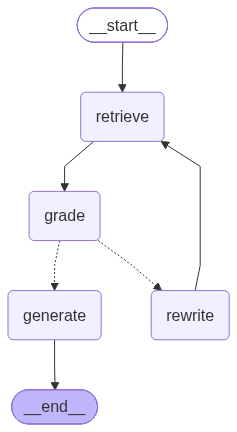

In [30]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

This renders the compiled graph as an image directly inside the notebook, which is a useful way to double-check that every node and edge connects the way it was intended to before running the agent on a real question.


### Step 13 — Run the Agent


In [ ]:
result = agent.invoke({
    "question": "How does the Transformer work?",
    "retrieved_facts": [],
    "grade": "",
    "retry_count": 0,
    "final_answer": ""
})

print(result["final_answer"])

Retrieving for: 'How does the Transformer work?'
Grade: YES

FINAL ANSWER:
--- FINAL ANSWER ---
The Transformer is a sequence‑to‑sequence model that uses only attention mechanisms to link its encoder and decoder, eliminating recurrence and convolutions.

--- EXPLAINABILITY ---
We used the fact that performing models connect the encoder and decoder through an attention mechanism, that the Transformer is a new simple architecture based solely on attention mechanisms, and that it dispenses with recurrence and convolutions, contrasting with dominant sequence transduction models that rely on complex recurrent or convolutional neural networks.


`agent.invoke(...)` starts the graph at `START` with a freshly initialized state — an empty fact list, no grade yet, and a retry count of zero — and lets it run node by node, looping back through `rewrite` and `retrieve` as many times as needed, until it reaches `END`. The printed result is whatever ended up in `state["final_answer"]` once the graph finished.


# What We Learnt

By the end of this lab, a plain retrieval pipeline has been turned into an agent that checks its own results before answering, using LangGraph to wire retrieval, grading, rewriting, and generation into a graph that can loop back on itself instead of only moving forward.

**Key takeaways:**
- **Grading catches weak retrieval before it reaches the final answer** — instead of blindly answering with whatever was retrieved, the pipeline checks first.
- **Rewriting gives a bad question a second chance** — a vague or awkwardly phrased question doesn't have to be a dead end; it can be rephrased and searched again automatically.
- **A retry limit keeps the loop from running forever** — the pipeline always reaches an answer, even if no attempt ever gets a perfect grade.
- **LangGraph makes branching and looping possible** — something a plain top-to-bottom script can't do on its own, since conditional edges let the flow choose its next step based on the current state.
- **A shared state ties every step together** — each node reads and updates the same dictionary of information, which is how a rewritten question or an updated retry count carries forward into the next loop.
- **The graph structure can be visualized directly** — rendering it as an image is a quick way to confirm every node and edge is wired the way it was intended to be, before running it on a real question.
